## Athar Sale
#### Notebook to assist in the analysis of data output from the AS_data_collection.py tool

In [37]:
import re
import glob
import json
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import pycountry
import hashlib
import unicodedata
import collections
from bs4 import BeautifulSoup
from datetime import datetime
from tqdm import tqdm
from roman_arabic_numerals import conv

from deep_translator import GoogleTranslator
translator = GoogleTranslator()

from geopy.geocoders import Nominatim
geolocator = Nominatim(user_agent="geo_locator")

objs_file = glob.glob('AS_output_restricted.json')[0]            # change the filename to AS_output.json if you're working with the output of the data collection tool rather than the restricted dataset available in GitHub
with open(objs_file, 'r', encoding="utf-8") as data:
    data = json.load(data)

print(f"A total of {len(data)} listings were found")

A total of 5917 listings were found


In [36]:
## identify the object categories and print the number of listings per category
object_categories = set([x['obj_category'] for x in data])

# {'antiques',
#  'books_and_manuscripts',
#  'coins_and_stamps',
#  'jewelry_and_accessories',
#  'miscellaneous',
#  'paintings_and_handicrafts'}

for c in object_categories:
    print(f"Number of objects in the '{c}' category: {len([x for x in data if x['obj_category'] == c])}")

Number of objects in the 'antiques' category: 425
Number of objects in the 'miscellaneous' category: 666
Number of objects in the 'jewelry_and_accessories' category: 612
Number of objects in the 'paintings_and_handicrafts' category: 415
Number of objects in the 'books_and_manuscripts' category: 880
Number of objects in the 'coins_and_stamps' category: 2919


### Translate Seller Countries
##### translate to English (if necessary; you can also keep them in Arabic)

In [ ]:
# create a list of the countries 
countries = []
for o in [x for x in data if 'seller_country' in x.keys()]:
    if o['seller_country'] != '':
        pattern = r"[\u0600-\u06FF]+"                            # check for Arabic characters
        match = re.search(pattern, o['seller_country'])          # if there are Arabic characters, append the country name to a list
        if match and o['seller_country'] not in countries:       # to avoid duplicates, only append the country name if it's not already in the list
            countries.append(o['seller_country'])

english_countries = [translator.translate(x) for x in countries] # this can take a while if there are a lot of country names
print(english_countries)

countries_dict = {countries[i]: english_countries[i] for i in range(len(countries))}
print(countries_dict)                                            # make a dictionary of the original country names (Arabic) and their English translations

for x in data:                                                   # use the dictionary to replace the country names
    x['seller_country'] = countries_dict.get(x['seller_country'])

print(data[0])

In [27]:
# I went through the list of seller countries and manually identified locations belonging to Iraq as well as Palestine, Yemen, Sudan, and Syria
# using these lists, we can identify objects being sold by sellers in each country, and save separate JSONs for each set of artifacts
# this needed to be done manually because sometimes cities are indicated as the seller's location (rather than countries), also there are occasionally typos in country/place names

iraq_sellers = ['Iraq',                                                             # 53 objects
                'iraq',
                'العراق',
                'الغراق',
                'العراق Iraq',
                'سوريا العراق اللبنان تركيا',
                'سوريا-العراق-تركيا',
                'العراق(Iraq)',
                'تركيا-العراق-سوري',
                'تركيا-العراق-سوريا',
                'سوريا العراق اللبنان تركيا',
                'سوريا-العراق-تركيا']

palestine_sellers = ['Palestine', 'Israel', 'فلسطين', 'فلسطين الداخل', 'فلسطين / قطاع غزة']  # 27 objects

yemen_sellers = ['Yemen',                                                           # 220 objects
                 'Yemen_ Hadramout_Syun',
                 "Sana'a Yemen",
                 'Yemen_ Aden',
                 'Yemen - Yemen',
                 'Yaman',
                 'Yemen 00967777690447',
                 'اليمن',
                 'اليمن_حضرموت_سيئون',
                 'صنعاء اليمن',
                 'Yemen_ Aden',
                 'اليمن - Yemen',
                 'اليمن صنعاء',
                 'اليمن ????????',
                 'اليمن0096777790447',
                 'اليمن -حضرموت',
                 'الُيَمٌنَ',
                 'في اليمن والضحن متوفر الى جميع الدول',
                 'اليمن حضرموت']

sudan_sellers = ['Sudan', 'السودان']                                                   # 18 objects

syria_sellers = ['Syria',
                 'syria',
                 'سوريا',
                 'سورية',
                 'ينبع',
                 'سوريا دمشق',
                 'سوريا-العراق-تركيا',
                 'ليبيا مصر سوريا',
                 'سوريا - ادلب',
                 'سوريا - syria',
                 '.سوريا']

sellers_lists = [iraq_sellers, palestine_sellers, yemen_sellers, sudan_sellers, syria_sellers]
countries = ['IRAQ', 'PALESTINE', 'YEMEN', 'SUDAN', 'SYRIA']

# output JSON for each country that holds a list of objects being sold by sellers based in that country
for seller in sellers_lists:
    objs = [x for x in data if x['seller_country'] in seller]
    if len(objs) > 0:
        with open(f"AS_{countries[sellers_lists.index(seller)]}.json", "w", encoding='utf8') as file:
            json.dump(objs, file, ensure_ascii=False)

### Plot distribution of sellers by number of listings (in the whole dataset)

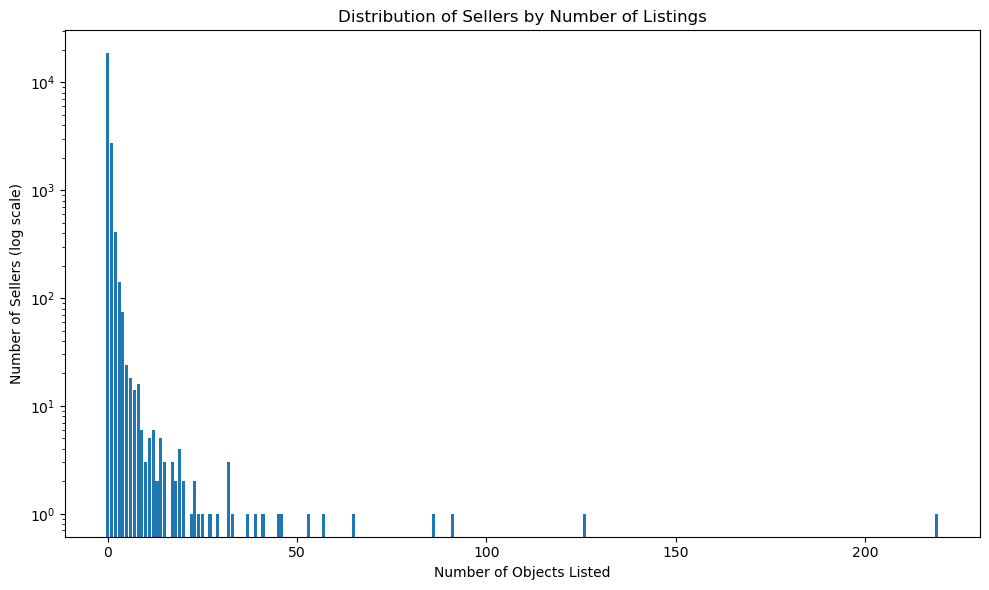

In [18]:
data = [                                                                         # (number_of_sellers, number_of_listings)
    (1,219),(1,126),(1,91),(1,86),(1,65),(1,57),(1,53),(1,46),(1,45),            # frankly I had to prepare this through manual examination of AS shops as of March 2 2026
    (1,41),(1,39),(1,37),(1,33),(3,32),(1,29),(1,27),(1,25),(1,24),
    (2,23),(1,22),(2,20),(4,19),(2,18),(3,17),(3,15),(5,14),(2,13),
    (6,12),(5,11),(3,10),(6,9),(16,8),(14,7),(18,6),(24,5),(74,4),
    (142,3),(413,2),(2771,1),(18625,0)
]

data_sorted = sorted(data, key=lambda x: x[1])                                   # sort the data by number of listings

objects = [x[1] for x in data_sorted]
sellers = [x[0] for x in data_sorted]

plt.figure(figsize=(10,6))
plt.bar(objects, sellers)
plt.yscale('log')                                                                # logarithmic scale to reveal long tail
plt.xlabel("Number of Objects Listed")
plt.ylabel("Number of Sellers (log scale)")
plt.title("Distribution of Sellers by Number of Listings")
plt.tight_layout()

plt.savefig("seller_distribution.png", dpi=300, bbox_inches="tight")             # save the plot
plt.show()

## Analysis of Iraq Objects

In [ ]:
# open file of objects being sold by sellers based in Iraq
iraq_objs = glob.glob('AS_IRAQ.json')[0]
with open(iraq_objs, 'r', encoding="utf-8") as iraq_data:
    iraq_data = json.load(iraq_data)
    
iraq_sellers = set([x['seller_name'] for x in iraq_data])             # create a list of sellers based in Iraq

# print objects with evaluation certificate; currently only 1 indicates that such a certificate is available
print([x for x in iraq_data if x['evaluation_certificate'] == True])

In [33]:
## identify the object categories and print the number of listings per category
object_categories = set([x['obj_category'] for x in iraq_data])

# {'antiques',
#  'books_and_manuscripts',
#  'coins_and_stamps',
#  'jewelry_and_accessories',
#  'miscellaneous',
#  'paintings_and_handicrafts'}

for c in object_categories:
    print(f"Number of objects in the '{c}' category: {len([x for x in iraq_data if x['obj_category'] == c])}")

Number of objects in the 'antiques' category: 0
Number of objects in the 'miscellaneous' category: 0
Number of objects in the 'jewelry_and_accessories' category: 0
Number of objects in the 'paintings_and_handicrafts' category: 0
Number of objects in the 'books_and_manuscripts' category: 0
Number of objects in the 'coins_and_stamps' category: 0


In [81]:
# write Iraqi object data to CSV for manual analysis, because I want to review listings and manually tag them as either 'potentially suspicious' or 'likely licit'
# this is based on whether they have been presented by the seller as older than 200 years or of particular artistic, cultural, or historical significance
# thus potentially violating Iraq's Law No. 55 (2002) on Antiquities and Heritage
df = pd.DataFrame(iraq_data)
df.to_csv('iraq_objects.csv', index=False, encoding='utf-16', sep=';') 

In [ ]:
# I went manually through the 46 available listings and classified them as either likely licit (0) or possibility illicit (1)
# for anyone running this locally, I would strongly encourage you to either stop here, or to conduct the same manual analysis
# if you use the classification below, it may not be accurate, depending on which dataset you're using and when the data collection occurred
red_flags = [1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1]
df['suspicious'] = red_flags                                                        # add a df column that reports whether the listing has been flagged as potentially illicit
df['suspicious'] = df['suspicious'].astype('bool')
df.loc[df['suspicious'] == 0, 'suspicious'] = False
df.loc[df['suspicious'] == 1, 'suspicious'] = True

sus = df.loc[df['suspicious'] == True]                                              # create a new df just for objects which are potentially illicit
print(len(sus['seller_name'].unique()))                                             # print the number of unique sellers of these objects
sus.head(25)                                                                        # display the first 25 rows of the df

In [ ]:
# print the name of any seller who has listed more than one object, as well as the URLs of their listings
sellers = [x for x in sus['seller_name'].unique()]
for s in sellers:
    if len(sus.loc[sus['seller_name'] == s]) > 1:
        print(s, [x['listing_url'] for x in [sus.loc[sus['seller_name'] == s]]])

In [134]:
# remove times from listing publication dates and print all
pub_dates = [x.partition(" ")[0] for x in sus['publication_date'].unique()]
pub_dates.sort()
print(pub_dates)

['2021-04-22',
 '2021-09-14',
 '2021-11-29',
 '2021-11-29',
 '2022-03-13',
 '2022-04-12',
 '2022-09-22',
 '2022-10-18',
 '2023-02-14',
 '2023-08-22',
 '2023-08-28',
 '2023-09-29',
 '2023-11-02',
 '2023-11-15',
 '2023-12-25',
 '2024-01-30',
 '2024-03-20',
 '2024-03-20',
 '2024-03-20',
 '2024-03-20',
 '2024-03-20',
 '2024-03-20',
 '2024-07-18',
 '2025-01-24',
 '2026-02-06']

## Pseudonimise and Redact Data
#### If you will share updated data gathered by the data collection tool, I would strongly recommend redacting personal information like names and phone numbers, as well as identifying information like URLs. You can use the following cells to do this

In [36]:
def pseudonimise(input_str):
    '''
    Generates static, unique hashes based on a string. The hashes created are consistent, meaning they can be used as stable pseudonyms

    Args
    ---
    :param input_str, string from which the hash is generated

    :return hashed ID
    '''
    h = hashlib.new('sha256')
    h.update(input_str.encode())
    hx = h.hexdigest()
    return str(int(hx, base=16))[:15]

for x in data:
    x['seller_url'] = pseudonimise(x['seller_url'])
    x['listing_url'] = pseudonimise(x['listing_url'])
    x['seller_name'] = pseudonimise(x['seller_name'])
    x['seller_phone_number'] = f"{x['seller_phone_number'][:5]}[redacted]" if 'seller_phone_number' in x.keys() else ""    # this retains the first five characters, allowing you to still examine the country code without compromising the whole phone number

In [ ]:
# sometimes the seller includes their phone number in the listing description as well as (or instead of) on their profile
# go through the listing descriptions and identify potential phone numbers, then redact all digits after the 5th
for x in data:
    if x['description'] != '':
        text = x['description']
        matches = re.findall(r'(?:\d\s*){9,}', text)
        for m in matches:
            x['description'] = x['description'].replace(m, f"{m[:5]}[phone number redacted]")

In [51]:
# save the final, sanitised version of the data
with open("AS_output_redacted.json", "w", encoding='utf8') as file:
    json.dump(data, file, ensure_ascii=False)